Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-0.5 pkt] Użyj zbalansowania klas w regresji logistycznej (parametr `class_weight`). Porównaj z modelem podstawowym
1. [0-1 pkt] Porównaj różne techniki podpróbkownia (*undersampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Podpróbkowanie losowe
   2. [Cluster Centroids](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.ClusterCentroids.html#clustercentroids)
   3. *Edited Nearest Neighbours* (patrz ćwiczenia)
1. [0-2 pkt] Porównaj różne techniki nadpróbkowania (*oversampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Nadpróbkowanie losowe
   2. [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
   3. [Borderline SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html#)
   3. [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html)
1. [0-1 pkt] Przeprowadź dostrajanie progu (*threshold tuning*) tj. użyj innych progów odcięcia klasy pozytywnej w regresji logistycznej. Możesz wykorzystać np. metody opisane [tutaj](https://scikit-learn.org/stable/modules/classification_threshold.html). Optymalizuj względem AUPRC
1. [0-1 pkt] Użyj przynajmniej jednego innego klasyfikatora poznanego na zajęciach i porównaj jego wyniki z regresją logistyczną
1. [0-1.5 pkt] Zaimplementuj fokalną funkcję kosztu (*focal loss*) w `scikit-learn`. W tym celu, wyjątkowo, **możesz skorzystać z narzędzi generatywnej sztucznej inteligencji**
1. [0-2 pkt] Sporządź analizę porównawczą technik / modeli wyżej, uwzględniając podejścia podstawowe (*baseline*). Zwizualizuj krzywe ROC i PRC
1. [0-1 pkt] Skomentuj uzyskane wyniki

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

In [3]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.6.1'

### Załadowanie danych

In [4]:
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets['y']

In [5]:
X_sel = X[['balance', 'duration', 'education']]
idx = X_sel.dropna().index
X_sel = X_sel.loc[idx]
y_sel = y.loc[idx]

In [6]:
label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y_sel.values)

In [7]:
enc = OneHotEncoder(drop='first', sparse_output=False)
X_trans = X_sel.drop(columns=['education']).join(
    enc.fit_transform(X_sel[['education']]))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_trans, y_trans,
                                                    test_size=0.2, random_state=0)

### Regresja logistyczna


In [9]:
logreg = LogisticRegression(random_state=0).fit(X_train, y_train)
y_train_pred = logreg.predict(X_train)
y_train_pred_proba = logreg.predict_proba(X_train)[:, 1]
y_test_pred = logreg.predict(X_test)
y_test_pred_proba = logreg.predict_proba(X_test)[:, 1]

In [10]:
confusion_matrix(y_train, y_train_pred)

array([[30173,   452],
       [ 3358,   700]])

In [11]:
confusion_matrix(y_test, y_test_pred)

array([[7570,  122],
       [ 825,  154]])

In [12]:
roc_auc_score(y_train, y_train_pred_proba), roc_auc_score(y_test, y_test_pred_proba)

(np.float64(0.8148638657828828), np.float64(0.8148813592993158))

In [13]:
average_precision_score(y_train, y_train_pred_proba), average_precision_score(y_test, y_test_pred_proba)

(np.float64(0.40083384565216906), np.float64(0.37618735285442156))

### Zadanie 1

In [14]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1])
weight = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
print(f"Waga klasy 0: {weight[0]:.4f}")
print(f"Waga klasy 1: {weight[1]:.4f}")

Waga klasy 0: 0.5663
Waga klasy 1: 4.2734


In [15]:
logreg_bal = LogisticRegression(random_state=0, class_weight='balanced').fit(X_train, y_train)

In [16]:
bal_y_train_pred = logreg_bal.predict(X_train)
bal_y_train_proba = logreg_bal.predict_proba(X_train)[:, 1]
bal_y_test_pred = logreg_bal.predict(X_test)
bal_y_test_proba = logreg_bal.predict_proba(X_test)[:, 1]

In [17]:
confusion_matrix(y_train, bal_y_train_pred)

array([[24876,  5749],
       [ 1440,  2618]])

In [18]:
confusion_matrix(y_test, bal_y_test_pred)

array([[6245, 1447],
       [ 343,  636]])

In [19]:
roc_auc_score(y_train, bal_y_train_proba), roc_auc_score(y_test, bal_y_test_proba)

(np.float64(0.8161699801852726), np.float64(0.8170468289620246))

In [20]:
average_precision_score(y_train, bal_y_train_proba), average_precision_score(y_test,bal_y_test_proba)

(np.float64(0.4008202225715665), np.float64(0.37638942603907105))

Wyniki auroc i auprc są prawie identyczne z baseline, natomiast zmianę widać w macierzach pomyłek. Widać, że model po zbalansowaniu znacznie częściej daje wynik positive. Dużo częściej (prawie 4x) łapie true positive, ale także pojawiło się znacznie więcej false positive.

### Zadanie 2

#### Próbkowanie losowe

In [21]:
from imblearn.under_sampling import RandomUnderSampler

sampling_ratios = [1.0,0.5,0.3,0.2]

for ratio in sampling_ratios:
  rus = RandomUnderSampler(sampling_strategy= ratio,random_state=0)
  X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print(np.unique(y_train_rus, return_counts=True))
  logreg_rus = LogisticRegression(random_state=0).fit(X_train_rus, y_train_rus)
  rus_y_train_pred = logreg_rus.predict(X_train_rus)
  rus_y_train_proba = logreg_rus.predict_proba(X_train_rus)[:, 1]
  rus_y_test_pred = logreg_rus.predict(X_test)
  rus_y_test_proba = logreg_rus.predict_proba(X_test)[:, 1]
  print("Train")
  print(confusion_matrix(y_train_rus, rus_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, rus_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_rus, rus_y_train_proba),roc_auc_score(y_test, rus_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_rus, rus_y_train_proba),average_precision_score(y_test, rus_y_test_proba))

Ratio:  1.0
(array([0, 1]), array([4058, 4058]))
Train
[[3303  755]
 [1437 2621]]
Test
[[6224 1468]
 [ 345  634]]
auroc
0.8144938072662996 0.816819485854
auprc
0.8018746803521457 0.373557042826695
Ratio:  0.5
(array([0, 1]), array([8116, 4058]))
Train
[[7434  682]
 [2262 1796]]
Test
[[7057  635]
 [ 548  431]]
auroc
0.8129846404075358 0.8152290136549283
auprc
0.6798715101573235 0.37333806803481534
Ratio:  0.3
(array([0, 1]), array([13526,  4058]))
Train
[[12931   595]
 [ 2692  1366]]
Test
[[7362  330]
 [ 674  305]]
auroc
0.8154354733052682 0.8149946324717137
auprc
0.5842028446074035 0.3754363293525816
Ratio:  0.2
(array([0, 1]), array([20290,  4058]))
Train
[[19764   526]
 [ 3051  1007]]
Test
[[7487  205]
 [ 763  216]]
auroc
0.8153126207691772 0.8148720637283101
auprc
0.4959232715216065 0.376516378556372


Auroc jest prawie identyczny dla wszystkich, losowe podpróbkowanie nie poprawia jego wyników. Auprc jest podobny do baseline na zbiorach testowych, ale na zbiorach treningowych widać różnicę. Przy większej liczbie próbek, na zbiorach trenigowych są uzyskiwane lepsze wyniki, natomiast nie przekłada się to na zbiór testowy. Oznacza to że model dopasowuje się do danych ale ma problemy z generalizacją.

#### Cluster Centroids

In [22]:
from imblearn.under_sampling import ClusterCentroids

sampling_ratios = [1.0,0.5,0.3,0.2]

for ratio in sampling_ratios:
  cc = ClusterCentroids(sampling_strategy= ratio,random_state=0)
  X_train_cc, y_train_cc = cc.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print(np.unique(y_train_cc, return_counts=True))
  logreg_cc = LogisticRegression(random_state=0).fit(X_train_cc, y_train_cc)
  cc_y_train_pred = logreg_cc.predict(X_train_cc)
  cc_y_train_proba = logreg_cc.predict_proba(X_train_cc)[:, 1]
  cc_y_test_pred = logreg_cc.predict(X_test)
  cc_y_test_proba = logreg_cc.predict_proba(X_test)[:, 1]
  print("Train")
  print(confusion_matrix(y_train_cc, cc_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, cc_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_cc, cc_y_train_proba),roc_auc_score(y_test, cc_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_cc, cc_y_train_proba),average_precision_score(y_test, cc_y_test_proba))

Ratio:  1.0
(array([0, 1]), array([4058, 4058]))
Train
[[2868 1190]
 [1421 2637]]
Test
[[5200 2492]
 [ 373  606]]
auroc
0.7164137502517101 0.7147288853760484
auprc
0.6749655451409813 0.2995578311178581
Ratio:  0.5
(array([0, 1]), array([8116, 4058]))
Train
[[7451  665]
 [2947 1111]]
Test
[[7412  280]
 [ 723  256]]
auroc
0.7317818595617368 0.7532457478074405
auprc
0.5486989696503914 0.3341228551795723
Ratio:  0.3
(array([0, 1]), array([13526,  4058]))
Train
[[13040   486]
 [ 3295   763]]
Test
[[7549  143]
 [ 805  174]]
auroc
0.7522913266288819 0.7862543204486094
auprc
0.46906757948869604 0.36028890603608144
Ratio:  0.2
(array([0, 1]), array([20290,  4058]))
Train
[[19840   450]
 [ 3360   698]]
Test
[[7565  127]
 [ 819  160]]
auroc
0.7813357195480709 0.8068012505995643
auprc
0.42901862223716913 0.37274558389753615


Podpróbkowanie Cluster Centroids daje gorsze wyniki niż RUS, tym gorsze im więcej próbek jest usuwane (wyższe ratio). Im niższe ratio - tym samym zbiór treningowy jest bardziej podobny do baseline - tym wyższe wyniki, bliższe do tych z baseline.

#### Edited Nearest Neighbours

In [23]:
neighbours_count = [3,5,7]

for neighbors in neighbours_count:
  enn = EditedNearestNeighbours(n_neighbors=neighbors)
  X_train_enn, y_train_enn = enn.fit_resample(X_train, y_train)
  logreg_enn = LogisticRegression(random_state=0,max_iter=1000).fit(X_train_enn, y_train_enn)
  enn_y_train_pred = logreg_enn.predict(X_train_enn)
  enn_y_train_proba = logreg_enn.predict_proba(X_train_enn)[:, 1]
  enn_y_test_pred = logreg_enn.predict(X_test)
  enn_y_test_proba = logreg_enn.predict_proba(X_test)[:, 1]
  print(np.unique(y_train_enn, return_counts=True))
  print("Train")
  print(confusion_matrix(y_train_enn, enn_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, enn_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_enn, enn_y_train_proba),roc_auc_score(y_test, enn_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_enn, enn_y_train_proba),average_precision_score(y_test, enn_y_test_proba))

(array([0, 1]), array([23708,  4058]))
Train
[[23253   455]
 [ 2362  1696]]
Test
[[7153  539]
 [ 573  406]]
auroc
0.8723376643112194 0.8192095099534319
auprc
0.6500107379496832 0.37828399335267227
(array([0, 1]), array([20894,  4058]))
Train
[[20404   490]
 [ 2082  1976]]
Test
[[6899  793]
 [ 498  481]]
auroc
0.8915292546861548 0.8193235798890587
auprc
0.7236727525094092 0.37834792973741543
(array([0, 1]), array([18806,  4058]))
Train
[[18323   483]
 [ 1867  2191]]
Test
[[6698  994]
 [ 452  527]]
auroc
0.9049384989124252 0.8196762804117884
auprc
0.7692225704051746 0.37830863822831295


ENN usuwa najmniej próbek ze wszystkich podejść, wyniki są natomiast bardzo podobne jak dla baseline. Poprawił się wynik auroc dla zbioru treningowego, ale bez wpływu na wyniki na zbiorze testowym.

### Zadanie 3

#### Nadpróbkowanie losowe

In [24]:
from imblearn.over_sampling import RandomOverSampler

sampling_ratios = [1.0,0.5,0.3]

for ratio in sampling_ratios:
  ros = RandomOverSampler(sampling_strategy= ratio,random_state=0)
  X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print(np.unique(y_train_ros, return_counts=True))
  logreg_ros = LogisticRegression(random_state=0).fit(X_train_ros, y_train_ros)
  ros_y_train_pred = logreg_ros.predict(X_train_ros)
  ros_y_train_proba = logreg_ros.predict_proba(X_train_ros)[:,1]
  ros_y_test_pred = logreg_ros.predict(X_test)
  ros_y_test_proba = logreg_ros.predict_proba(X_test)[:,1]
  print("Train")
  print(confusion_matrix(y_train_ros, ros_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, ros_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_ros, ros_y_train_proba),roc_auc_score(y_test, ros_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_ros, ros_y_train_proba), average_precision_score(y_test, ros_y_test_proba))

Ratio:  1.0
(array([0, 1]), array([30625, 30625]))
Train
[[24865  5760]
 [10868 19757]]
Test
[[6241 1451]
 [ 343  636]]
auroc
0.8156458446314034 0.8170974234270698
auprc
0.804868734757664 0.3766725980337818
Ratio:  0.5
(array([0, 1]), array([30625, 15312]))
Train
[[28169  2456]
 [ 8390  6922]]
Test
[[7035  657]
 [ 541  438]]
auroc
0.8162804800290022 0.8163621437605206
auprc
0.6878616214507441 0.37658520088998815
Ratio:  0.3
(array([0, 1]), array([30625,  9187]))
Train
[[29324  1301]
 [ 6077  3110]]
Test
[[7371  321]
 [ 678  301]]
auroc
0.8139864520184911 0.814809252227086
auprc
0.5799125256626176 0.3760448936618489


Wyniki są prawie takie same jak baseline, znowu widoczna znaczna różnica między test i train w auprc, przy ratio 1.0 - model jest przeuczony.

### SMOTE

In [25]:
from imblearn.over_sampling import SMOTE

params = [(1.0, 3), (1.0, 5), (1.0, 7), (0.5,3), (0.5, 5),(0.5, 7)]

for ratio, neighbors in params:
  smote = SMOTE(sampling_strategy=ratio, k_neighbors=neighbors, random_state=0)
  X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print("Neighbors: ",neighbors)
  print(np.unique(y_train_smote, return_counts=True))
  logreg_smote = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_smote, y_train_smote)
  smote_y_train_pred = logreg_smote.predict(X_train_smote)
  smote_y_train_proba = logreg_smote.predict_proba(X_train_smote)[:,1]
  smote_y_test_pred = logreg_smote.predict(X_test)
  smote_y_test_proba = logreg_smote.predict_proba(X_test)[:,1]
  print("Train")
  print(confusion_matrix(y_train_smote, smote_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, smote_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_smote, smote_y_train_proba),roc_auc_score(y_test, smote_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_smote, smote_y_train_proba), average_precision_score(y_test, smote_y_test_proba))

Ratio:  1.0
Neighbors:  3
(array([0, 1]), array([30625, 30625]))
Train
[[24808  5817]
 [10781 19844]]
Test
[[6207 1485]
 [ 340  639]]
auroc
0.8168980188921282 0.8146350266676653
auprc
0.804382929897697 0.3756541885501372
Ratio:  1.0
Neighbors:  5
(array([0, 1]), array([30625, 30625]))
Train
[[24822  5803]
 [10684 19941]]
Test
[[6204 1488]
 [ 340  639]]
auroc
0.8191311881382757 0.8147047434502078
auprc
0.805806104261607 0.3752944762493198
Ratio:  1.0
Neighbors:  7
(array([0, 1]), array([30625, 30625]))
Train
[[24799  5826]
 [10808 19817]]
Test
[[6208 1484]
 [ 340  639]]
auroc
0.8181424635735111 0.8154185105095726
auprc
0.8047719694515709 0.375441579201061
Ratio:  0.5
Neighbors:  3
(array([0, 1]), array([30625, 15312]))
Train
[[28155  2470]
 [ 8425  6887]]
Test
[[7031  661]
 [ 538  441]]
auroc
0.8169302305248118 0.8142294741840745
auprc
0.6859113035766201 0.3756368869944243
Ratio:  0.5
Neighbors:  5
(array([0, 1]), array([30625, 15312]))
Train
[[28150  2475]
 [ 8411  6901]]
Test
[[7032  

SMOTE daje podobne wyniki co ROS. SMOTE jest niedostosowane do zmiennych binarnych, robi interpolacje między próbkami, co dla zmiennych kategorycznych daje nic nie wnoszące wyniki.

#### Borderline SMOTE

In [26]:
from imblearn.over_sampling import BorderlineSMOTE

params = [(1.0, 3), (1.0, 5), (1.0, 7), (0.5,3), (0.5, 5),(0.5, 7)]

for ratio, neighbors in params:
  bsmote = BorderlineSMOTE(sampling_strategy=ratio, k_neighbors=neighbors, random_state=0)
  X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print("Neighbors: ",neighbors)
  print(np.unique(y_train_bsmote, return_counts=True))
  logreg_bsmote = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_bsmote, y_train_bsmote)
  bsmote_y_train_pred = logreg_bsmote.predict(X_train_bsmote)
  bsmote_y_train_proba = logreg_bsmote.predict_proba(X_train_bsmote)[:,1]
  bsmote_y_test_pred = logreg_bsmote.predict(X_test)
  bsmote_y_test_proba = logreg_bsmote.predict_proba(X_test)[:,1]
  print("Train")
  print(confusion_matrix(y_train_bsmote, bsmote_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, bsmote_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_bsmote, bsmote_y_train_proba),roc_auc_score(y_test, bsmote_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_bsmote, bsmote_y_train_proba), average_precision_score(y_test, bsmote_y_test_proba))

Ratio:  1.0
Neighbors:  3
(array([0, 1]), array([30625, 30625]))
Train
[[24609  6016]
 [ 9550 21075]]
Test
[[6167 1525]
 [ 328  651]]
auroc
0.8326270416659725 0.8168322340656649
auprc
0.7989130686608517 0.3751720214795804
Ratio:  1.0
Neighbors:  5
(array([0, 1]), array([30625, 30625]))
Train
[[24627  5998]
 [ 9719 20906]]
Test
[[6178 1514]
 [ 329  650]]
auroc
0.8315723243315285 0.817412676078034
auprc
0.7991410645327464 0.3756583959652745
Ratio:  1.0
Neighbors:  7
(array([0, 1]), array([30625, 30625]))
Train
[[24633  5992]
 [ 9678 20947]]
Test
[[6171 1521]
 [ 329  650]]
auroc
0.8327972752686381 0.816871541051632
auprc
0.7998771108423008 0.3753961923985046
Ratio:  0.5
Neighbors:  3
(array([0, 1]), array([30625, 15312]))
Train
[[27821  2804]
 [ 8277  7035]]
Test
[[6971  721]
 [ 523  456]]
auroc
0.8291246699933892 0.8163369129249338
auprc
0.6743179104537621 0.3754794451756599
Ratio:  0.5
Neighbors:  5
(array([0, 1]), array([30625, 15312]))
Train
[[27848  2777]
 [ 8299  7013]]
Test
[[6973 

Wyniki auroc i auprc ponownie są podobne do poprzednich i nie przynoszą znaczacej poprawy. Dla macierzy pomyłek można zauważyć nieznaczną poprawę jeśli chodzi o poprawną klasyfikację positive w porównaniu do SMOTE

#### ADASYN

In [27]:
from imblearn.over_sampling import ADASYN

params = [(1.0, 3), (1.0, 5), (1.0, 7), (0.5,3), (0.5, 5),(0.5, 7)]

for ratio, neighbors in params:
  adasyn = ADASYN(sampling_strategy=ratio, n_neighbors=neighbors, random_state=0)
  X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
  print("Ratio: ",ratio)
  print("Neighbors: ",neighbors)
  print(np.unique(y_train_adasyn, return_counts=True))
  logreg_adasyn = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_adasyn, y_train_adasyn)
  adasyn_y_train_pred = logreg_adasyn.predict(X_train_adasyn)
  adasyn_y_train_proba = logreg_adasyn.predict_proba(X_train_adasyn)[:,1]
  adasyn_y_test_pred = logreg_adasyn.predict(X_test)
  adasyn_y_test_proba = logreg_adasyn.predict_proba(X_test)[:,1]
  print("Train")
  print(confusion_matrix(y_train_adasyn, adasyn_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, adasyn_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train_adasyn, adasyn_y_train_proba),roc_auc_score(y_test, adasyn_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train_adasyn, adasyn_y_train_proba), average_precision_score(y_test, adasyn_y_test_proba))

Ratio:  1.0
Neighbors:  3
(array([0, 1]), array([30625, 30065]))
Train
[[23990  6635]
 [11417 18648]]
Test
[[6020 1672]
 [ 307  672]]
auroc
0.7835307549289464 0.8116609751213338
auprc
0.7575401952728518 0.37355377003005175
Ratio:  1.0
Neighbors:  5
(array([0, 1]), array([30625, 29920]))
Train
[[24056  6569]
 [11510 18410]]
Test
[[6039 1653]
 [ 306  673]]
auroc
0.7836430197533559 0.8123323809356868
auprc
0.7569104733143532 0.37407928916394817
Ratio:  1.0
Neighbors:  7
(array([0, 1]), array([30625, 31074]))
Train
[[23680  6945]
 [11418 19656]]
Test
[[5944 1748]
 [ 300  679]]
auroc
0.7855020938825424 0.8122473928579206
auprc
0.7638876985339014 0.37396968259032337
Ratio:  0.5
Neighbors:  3
(array([0, 1]), array([30625, 15837]))
Train
[[27896  2729]
 [ 9785  6052]]
Test
[[6976  716]
 [ 526  453]]
auroc
0.7867788957143759 0.8128538624691055
auprc
0.6364772608499978 0.37461802123663546
Ratio:  0.5
Neighbors:  5
(array([0, 1]), array([30625, 15394]))
Train
[[28053  2572]
 [ 9526  5868]]
Test
[

Kolejny raz wyniki auroc i auprc na zbiorze testowym są podobne do poprzednich, w tym wypadku minimalnie gorsze.

Podsumowując, żadna z metod nadpróbkowania i podpróbkowania nie dało znaczącej poprawy wyników metryki auroc i auprc na zbiorze testowym.

### Zadanie 4 - threshold tuning

In [28]:
from sklearn.model_selection import TunedThresholdClassifierCV

base_lr = LogisticRegression(random_state=0, max_iter=1000)

tuned_clf = TunedThresholdClassifierCV(estimator=base_lr, scoring='average_precision', cv=5, n_jobs=-1, random_state=0)
tuned_clf.fit(X_train, y_train)

print(f"Best threshold: {tuned_clf.best_threshold_:.4f}")

tuned_y_train_proba = tuned_clf.predict_proba(X_train)[:, 1]
tuned_y_test_proba = tuned_clf.predict_proba(X_test)[:, 1]
tuned_y_test_pred = tuned_clf.predict(X_test)

print(confusion_matrix(y_test, tuned_y_test_pred))


Best threshold: 0.2115
[[7134  558]
 [ 573  406]]


Widać różnice względem baseline logistic regression. Zgodnie z oczekiwaniami model daje więcej false positive ale także true positive, czyli klasa pozytywna jest częściej wybierana przez model - udało się go lepiej zbalansować.

### Zadanie 5

Wykorzystam naive bayes, ponieważ pośród poznanych wcześniej klasyfikatorów domyślnie radzi sobie z klasami niezbalansowanymi.

In [29]:
from sklearn.naive_bayes import GaussianNB

bayes = GaussianNB()
bayes.fit(X_train, y_train)

bayes_y_train_pred = bayes.predict(X_train)
bayes_y_train_proba = bayes.predict_proba(X_train)[:,1]
bayes_y_test_pred = bayes.predict(X_test)
bayes_y_test_proba = bayes.predict_proba(X_test)[:,1]

print("Train")
print(confusion_matrix(y_train, bayes_y_train_pred))
print("Test")
print(confusion_matrix(y_test, bayes_y_test_pred))
print("auroc")
print(roc_auc_score(y_train, bayes_y_train_proba),roc_auc_score(y_test, bayes_y_test_proba))
print("auprc")
print(average_precision_score(y_train, bayes_y_train_proba), average_precision_score(y_test, bayes_y_test_proba))


Train
[[29477  1148]
 [ 2941  1117]]
Test
[[7406  286]
 [ 734  245]]
auroc
0.7796329910179942 0.776530754795054
auprc
0.36158612811127444 0.3386840238106788


Naiwny bayes radzi sobie gorzej niż regresja logistyczna. Wynika to prawdopodobnie z jego założenia, ze zmienne w zbiorze są od siebie niezależne, co niekoniecznie zachodzi w tym datasecie.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

for k in [3,5,7,9,11]:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)

  knn_y_train_pred = knn.predict(X_train)
  knn_y_train_proba = knn.predict_proba(X_train)[:,1]
  knn_y_test_pred = knn.predict(X_test)
  knn_y_test_proba = knn.predict_proba(X_test)[:,1]
  print("k =",k)
  print("Train")
  print(confusion_matrix(y_train, knn_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, knn_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train, knn_y_train_proba),roc_auc_score(y_test, knn_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train, knn_y_train_proba), average_precision_score(y_test, knn_y_test_proba))

k = 3
Train
[[29977   648]
 [ 2231  1827]]
Test
[[7335  357]
 [ 756  223]]
auroc
0.9418234739139617 0.668352883247097
auprc
0.6021286063093865 0.21646067581784925
k = 5
Train
[[29992   633]
 [ 2740  1318]]
Test
[[7418  274]
 [ 774  205]]
auroc
0.9154928797738908 0.7078554081897699
auprc
0.5183791548378978 0.24920423884959475
k = 7
Train
[[30042   583]
 [ 2924  1134]]
Test
[[7476  216]
 [ 803  176]]
auroc
0.8997287816457289 0.7294866666985372
auprc
0.48993771366506716 0.26794813984359245
k = 9
Train
[[30082   543]
 [ 3001  1057]]
Test
[[7499  193]
 [ 802  177]]
auroc
0.8886025326641253 0.7469171238759662
auprc
0.47360982455989603 0.2856866933269615
k = 11
Train
[[30108   517]
 [ 3072   986]]
Test
[[7512  180]
 [ 798  181]]
auroc
0.880448086420374 0.7585577018586361
auprc
0.46189303999463305 0.2970036409342382


KNN wypada najgorzej ze wszystkich klasyfikatorów. Przy niskich wartościach k widać spory overfitting, także wraz ze wzrostem k rośnie wynik wykorzsytanych metryk na zbiorze testowym

### Zadanie 6 - focal loss

In [31]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import minimize
from scipy.special import expit

class FocalLoss(BaseEstimator, ClassifierMixin):
  def __init__(self,gamma=2.0,C=1.0):
    self.gamma = gamma
    self.C = C

  def _focal_loss(self,w,X,y):
    logit = X @ w[1:] + w[0]
    p = np.clip(expit(logit), 1e-7, 1 - 1e-7)
    p_t = np.where(y == 1, p, 1 - p)
    reg = (1 / (2 * self.C)) * np.sum(w[1:]**2)
    return -np.mean((1 - p_t)**self.gamma * np.log(p_t)) + reg

  def fit(self,X,y):
    self.classes_ = np.unique(y)
    X_arr = np.array(X)
    y_arr = np.array(y)
    n_features = X_arr.shape[1]
    w0 = np.zeros(n_features+1)
    result = minimize(fun=self._focal_loss,x0=w0,args=(X_arr,y_arr), method='L-BFGS-B')
    self.bias_ = result.x[0]
    self.coef_ = result.x[1:]
    return self

  def predict_proba(self,X):
    logit = X @ self.coef_ + self.bias_
    p = np.clip(expit(logit), 1e-7, 1 - 1e-7)
    return np.c_[1 - p, p]

  def predict(self,X):
    return np.argmax(self.predict_proba(X), axis=1)

In [32]:
for gamma in [0.5,1.0,1.5,2.0,4.0]:
  fl = FocalLoss(gamma=gamma)
  fl.fit(X_train, y_train)
  fl_y_train_pred = fl.predict(X_train)
  fl_y_train_proba = fl.predict_proba(X_train)[:,1]
  fl_y_test_pred = fl.predict(X_test)
  fl_y_test_proba = fl.predict_proba(X_test)[:,1]

  print('gamma = ',gamma)
  print("Train")
  print(confusion_matrix(y_train, fl_y_train_pred))
  print("Test")
  print(confusion_matrix(y_test, fl_y_test_pred))
  print("auroc")
  print(roc_auc_score(y_train, fl_y_train_proba),roc_auc_score(y_test, fl_y_test_proba))
  print("auprc")
  print(average_precision_score(y_train, fl_y_train_proba), average_precision_score(y_test, fl_y_test_proba))

gamma =  0.5
Train
[[30190   435]
 [ 3383   675]]
Test
[[7575  117]
 [ 831  148]]
auroc
0.811907468241116 0.8154964605121489
auprc
0.39551884511988294 0.373570341358885
gamma =  1.0
Train
[[30197   428]
 [ 3393   665]]
Test
[[7575  117]
 [ 834  145]]
auroc
0.8120718842095734 0.8156396123056362
auprc
0.3955449314001499 0.37359632311785307
gamma =  1.5
Train
[[30204   421]
 [ 3405   653]]
Test
[[7577  115]
 [ 836  143]]
auroc
0.8121825006789309 0.8157321696340787
auprc
0.39552615740556757 0.373484509442945
gamma =  2.0
Train
[[30216   409]
 [ 3413   645]]
Test
[[7580  112]
 [ 840  139]]
auroc
0.8122339344806428 0.8157981681882188
auprc
0.39547858617201953 0.37339303383728295
gamma =  4.0
Train
[[30260   365]
 [ 3483   575]]
Test
[[7590  102]
 [ 858  121]]
auroc
0.8095765079812112 0.8138155556865787
auprc
0.3933143971309332 0.37138213300714207


AUROC miminalnie rośnie wraz ze wzrostem gamma, natomiast AUPRC spada, co jest ważniejszym wyznacznikiem przy niezbalansowanych danych.

### Zadanie 7

wyniki najlepszych modeli

In [33]:
baseline_proba = logreg.predict_proba(X_test)[:, 1]

balanced_proba = logreg_bal.predict_proba(X_test)[:, 1]

tuned_proba = tuned_clf.predict_proba(X_test)[:, 1]

bayes_proba = bayes.predict_proba(X_test)[:, 1]

enn_best = EditedNearestNeighbours(n_neighbors=7)
X_train_enn_best, y_train_enn_best = enn_best.fit_resample(X_train, y_train)
logreg_enn_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_enn_best, y_train_enn_best)
enn_best_proba = logreg_enn_best.predict_proba(X_test)[:, 1]

rus_best = RandomUnderSampler(sampling_strategy=0.2, random_state=0)
X_train_rus_best, y_train_rus_best = rus_best.fit_resample(X_train, y_train)
logreg_rus_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_rus_best, y_train_rus_best)
rus_best_proba = logreg_rus_best.predict_proba(X_test)[:, 1]

ros_best = RandomOverSampler(sampling_strategy=1.0, random_state=0)
X_train_ros_best, y_train_ros_best = ros_best.fit_resample(X_train, y_train)
logreg_ros_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_ros_best, y_train_ros_best)
ros_best_proba = logreg_ros_best.predict_proba(X_test)[:, 1]

smote_best = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=0)
X_train_smote_best, y_train_smote_best = smote_best.fit_resample(X_train, y_train)
logreg_smote_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_smote_best, y_train_smote_best)
smote_best_proba = logreg_smote_best.predict_proba(X_test)[:, 1]

bsmote_best = BorderlineSMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=0)
X_train_bsmote_best, y_train_bsmote_best = bsmote_best.fit_resample(X_train, y_train)
logreg_bsmote_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_bsmote_best, y_train_bsmote_best)
bsmote_best_proba = logreg_bsmote_best.predict_proba(X_test)[:, 1]

adasyn_best = ADASYN(sampling_strategy=0.5, n_neighbors=3, random_state=0)
X_train_adasyn_best, y_train_adasyn_best = adasyn_best.fit_resample(X_train, y_train)
logreg_adasyn_best = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_adasyn_best, y_train_adasyn_best)
adasyn_best_proba = logreg_adasyn_best.predict_proba(X_test)[:, 1]

knn_best = KNeighborsClassifier(n_neighbors=11)
knn_best.fit(X_train, y_train)
knn_best_proba = knn_best.predict_proba(X_test)[:, 1]

fl_best = FocalLoss(gamma=2.0)
fl_best.fit(X_train, y_train)
fl_best_proba = fl_best.predict_proba(X_test)[:, 1]

Baseline

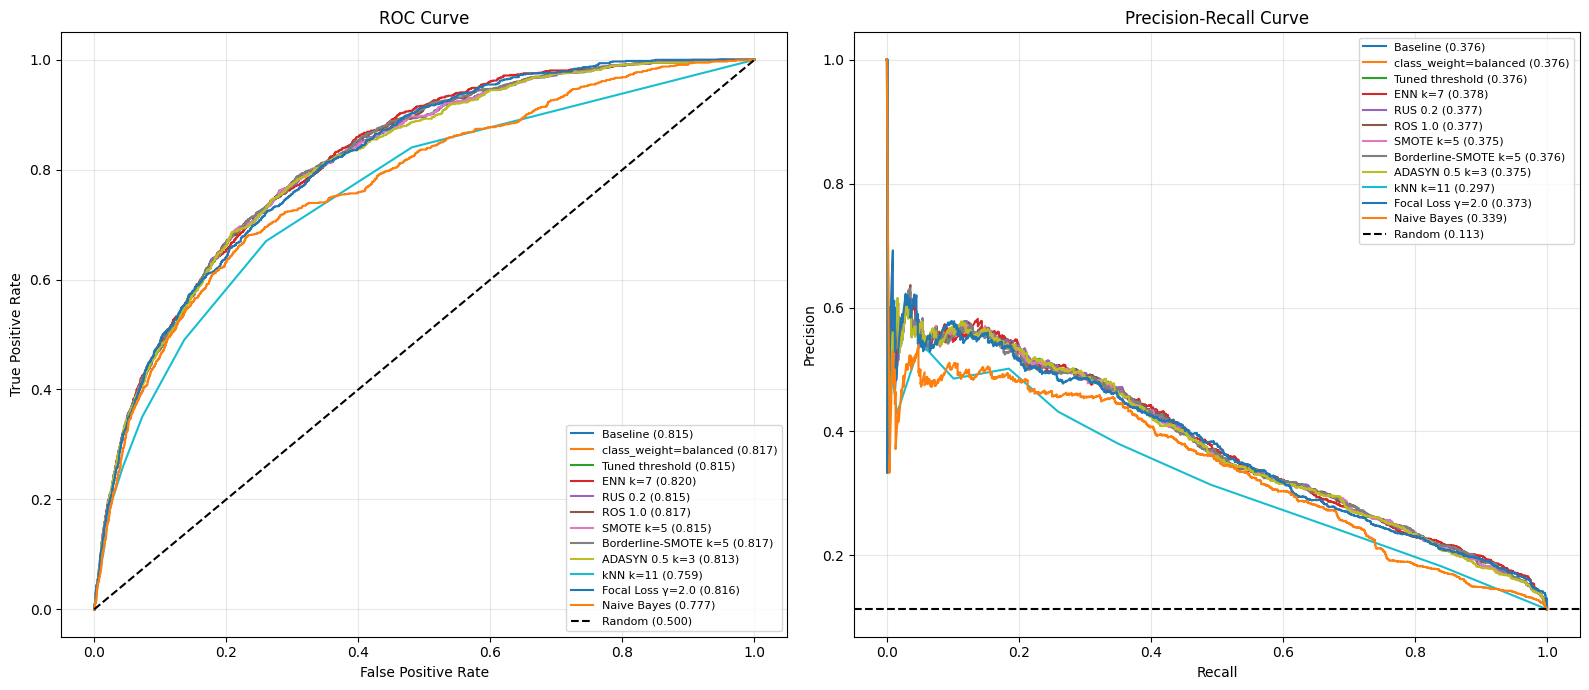

In [35]:
from sklearn.metrics import roc_curve, precision_recall_curve

models = [
    ("Baseline", baseline_proba),
    ("class_weight=balanced", balanced_proba),
    ("Tuned threshold", tuned_proba),
    ("ENN k=7", enn_best_proba),
    ("RUS 0.2", rus_best_proba),
    ("ROS 1.0", ros_best_proba),
    ("SMOTE k=5", smote_best_proba),
    ("Borderline-SMOTE k=5", bsmote_best_proba),
    ("ADASYN 0.5 k=3", adasyn_best_proba),
    ("kNN k=11", knn_best_proba),
    ("Focal Loss γ=2.0", fl_best_proba),
    ("Naive Bayes", bayes_proba),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name, proba in models:
    auroc = roc_auc_score(y_test, proba)
    auprc = average_precision_score(y_test, proba)

    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} ({auprc:.3f})")

axes[0].plot([0,1], [0,1], 'k--', label='Random (0.500)')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',
                label=f'Random ({y_test.mean():.3f})')

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Wszystkie modele radzą sobie bardzo podobnie, poza naive bayes oraz knn, które radzą sobie wyraźnie gorzej

### Zadanie 8

Żadna z zastosowanych metod radzenia sobie z niezbalansowaniem klas nie przyniosła widocznej poprawy rezultatu. Metryka AUPRC osiąga dla większości metod okolice 0.373 - 0.378.

Różne przetestowane w zadaniu 2 i 3 metody podpróbkowania i nadpróbkowania nie przyniosły oczekiwanej poprawy rezultatu, analogiczne wyniki przyniosły modyfikacje modelu (threshold tuning, class weight balanced). Mimo bardzo przybliżonych wyników auprc na zbiorze testowym, widać zmiany w macierzach pomyłek, gdzie metody próbujące poprawić balans klas faktycznie podnoszą reprezentację klasy niedoreprezentowanej w danych, przez co model faktycznie częściej wybiera ją jako odpowiedź.

Porównanie regresji logistycznej z innymi klasyfikatorami pokazało, że jest ona najodpowiedniejsza dla tego problemu, mimo że nie osiąga ona bardzo dobrych wyników.

Implementacja focal loss również dała wyniki porównywalne z baseline.